#### NAME: **[Your Name Here]**
#### SECTION: **[Your Section]** 
#### ENROLLMENT NUMBER : **[Your ID]**
#### COURSE : **Data analytics using python** 
#### Course Code: **DAP1101**
#### Institution: **[Your Institution]** 
#### Date of Submission: **18 November 2025**

#### ABOUT PROJECT :
##### This mini project analyzes a dataset of Spotify tracks to determine what factors contribute to a song's popularity. We will explore relationships between artist fame, song explicitness, duration, and album details.
##### The primary objective is to build a **Regression Model** to predict the **`track_popularity`** score (0-100) based on these features.

## Step 1: Problem Definition & Dataset Selection

**Dataset Source:** Spotify Data (`spotify_data clean.csv`)

**Description:**
- **Rows:** (Variable based on upload)
- **Features:** Track details (Duration, Explicit), Artist details (Popularity, Followers), and Album metadata.
- **Target Variable:** `track_popularity` (Numerical, 0-100).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Set visualization style
sns.set(style="whitegrid")
plt.style.use('fivethirtyeight')

In [2]:
# Load the dataset
try:
 df = pd.read_csv('spotify_data clean.csv')
 print("Dataset loaded successfully.")
except FileNotFoundError:
 print("Error: File not found. Please upload 'spotify_data clean.csv'.")

# Display first 5 rows
df.head()

Dataset loaded successfully.


,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39


## Step 2: Data Cleaning & Preparation

**Justification for Preprocessing:**
1. **Missing Data Handling:** We fill missing genres with 'Unknown' to avoid losing valid rows. We only drop rows where critical numerical data is missing.
2. **Feature Engineering (Genre):** Instead of discarding `artist_genres`, we create simple binary flags (e.g., `is_pop`, `is_rap`) to capture high-level genre information.
3. **Feature Engineering (Followers):** `artist_followers` is highly skewed (power law). We apply a **Log Transformation** (`log_followers`) to normalize this distribution for better model performance.
4. **Booleans & Dates:** We robustly map the `explicit` column to 0/1 and extract the `release_year`.

In [3]:
# 1. Handle Missing Values Robustly
# Fill missing genres instead of dropping them
df['artist_genres'] = df['artist_genres'].fillna('Unknown')
# Drop rows only if critical columns are missing
df.dropna(subset=['track_popularity', 'artist_popularity', 'album_release_date'], inplace=True)

# 2. Robust Explicit Column Conversion
# Handles 'TRUE', 'True', True, 1, etc.
def clean_explicit(val):
 if str(val).upper() == 'TRUE' or str(val) == '1':
    return 1
 return 0

df['explicit'] = df['explicit'].apply(clean_explicit)

# 3. Extract Year from Release Date
df['release_year'] = pd.to_datetime(df['album_release_date'], errors='coerce').dt.year
# Fallback for years that failed parsing (e.g., just '2022')
df['release_year'] = df['release_year'].fillna(df['album_release_date'].astype(str).str[:4])
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')

# 4. Feature Engineering: Log Transform Followers
# Use log1p (log(1+x)) to handle 0 followers and reduce skewness
df['log_artist_followers'] = np.log1p(df['artist_followers'])

# 5. Feature Engineering: Simplified Genres
# Create binary flags for major genres
df['is_pop'] = df['artist_genres'].astype(str).str.contains('pop', case=False).astype(int)
df['is_rap'] = df['artist_genres'].astype(str).str.contains('rap|hip hop', case=False).astype(int)
df['is_rock'] = df['artist_genres'].astype(str).str.contains('rock|metal', case=False).astype(int)

# 6. Encode 'album_type'
le = LabelEncoder()
df['album_type_encoded'] = le.fit_transform(df['album_type'].astype(str))

# 7. Drop unused columns
cols_to_drop = ['track_id', 'track_name', 'artist_name', 'artist_genres', 
 'album_id', 'album_name', 'album_release_date', 'album_type', 'artist_followers']
df_model_data = df.drop(columns=cols_to_drop)

print(f"Data cleaned. New Shape: {df_model_data.shape}")
df_model_data.head()

Data cleaned. New Shape: (8582, 12)


,track_number,track_popularity,explicit,artist_popularity,album_total_tracks,track_duration_min,release_year,log_artist_followers,is_pop,is_rap,is_rock,album_type_encoded
0,4,0,1,77,9,1.55,2025,14.849699,0,0,0,0
1,1,0,1,64,1,3.07,2025,14.675628,0,1,0,2
2,1,4,1,48,1,2.55,2025,12.172014,0,0,0,2
3,8,30,1,77,9,1.69,2025,14.850015,0,0,0,0
4,2,0,1,48,2,2.39,2025,9.069122,0,0,0,2


## Step 3: Exploratory Data Analysis (EDA)

We will analyze the distribution of popularity and its relationship with artist fame and song content.

### EDA Question 1: What is the distribution of `track_popularity`?

```python
# Visualizing track popularity with histogram + KDE
# Shows central tendency, dispersion, and right-tail of hits
# Helps assess skewness and baseline prediction difficulty
```

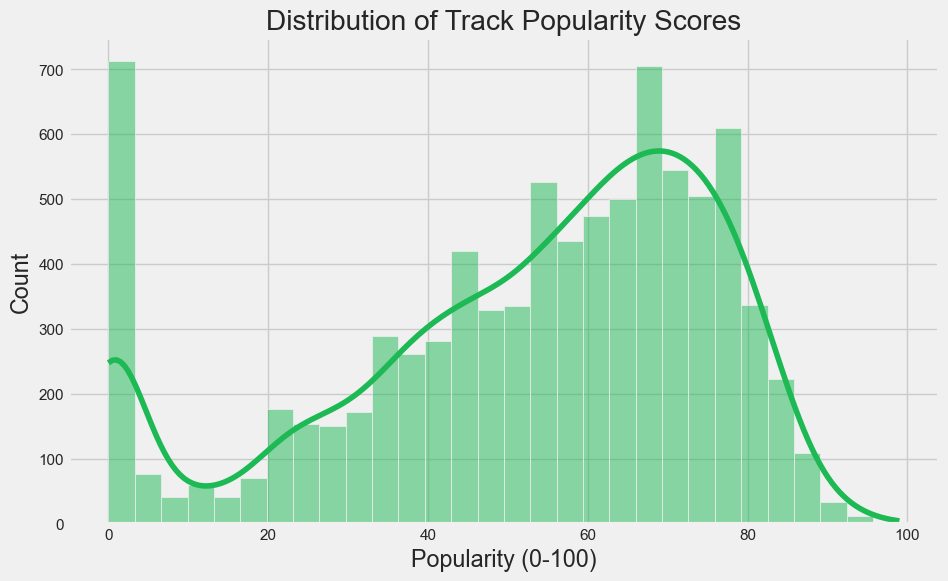

In [4]:
# Univariate Analysis: Distribution of Track Popularity
# Uses Spotify green with valid hex and density estimate
plt.figure(figsize=(10, 6))
sns.histplot(df['track_popularity'], kde=True, color='#1DB954', bins=30)
plt.title('Distribution of Track Popularity Scores')
plt.xlabel('Popularity (0-100)')
plt.show()

### EDA Question 2: Does artist popularity correlate with `track_popularity`?

```python
# Relating artist visibility to track outcomes
# Tests platform hypothesis: fame drives discovery and engagement
# Regression line summarizes average effect across the range
```

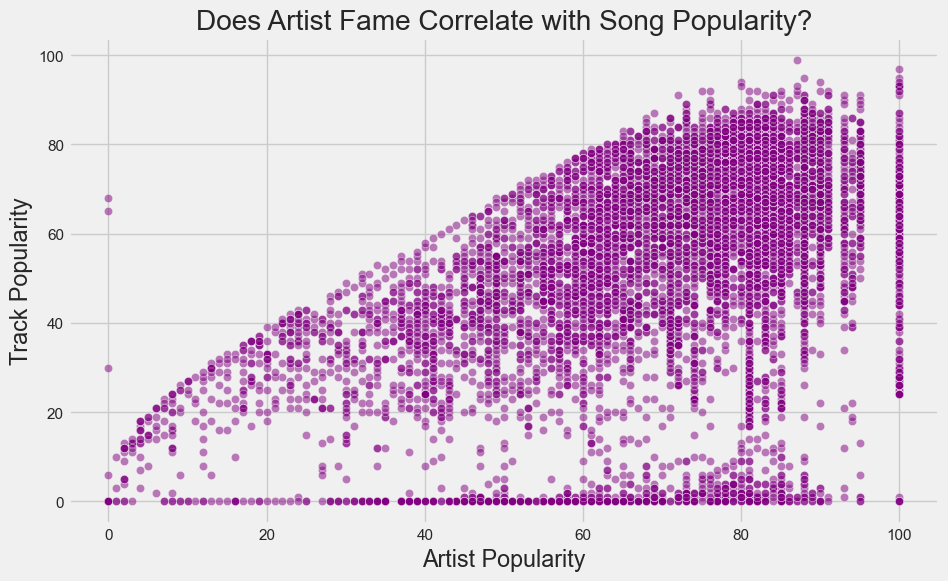

In [5]:
# Bivariate Analysis: Artist Popularity vs Track Popularity
plt.figure(figsize=(10, 6))
sns.scatterplot(x='artist_popularity', y='track_popularity', data=df, alpha=0.5, color='purple')
plt.title('Does Artist Fame Correlate with Song Popularity?')
plt.xlabel('Artist Popularity')
plt.ylabel('Track Popularity')
plt.show()

### EDA Question 3: Popularity differences for genre flags (pop/rap/rock)?

```python
# Melted view selecting tracks with a genre flag==1
# Compares medians and dispersion across genres
# Informs genre-aware curation and promotion
```

C:\Users\mauli\AppData\Local\Temp\ipykernel_17308\3144677157.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Genre', y='track_popularity', data=df_plot, palette='Set2')


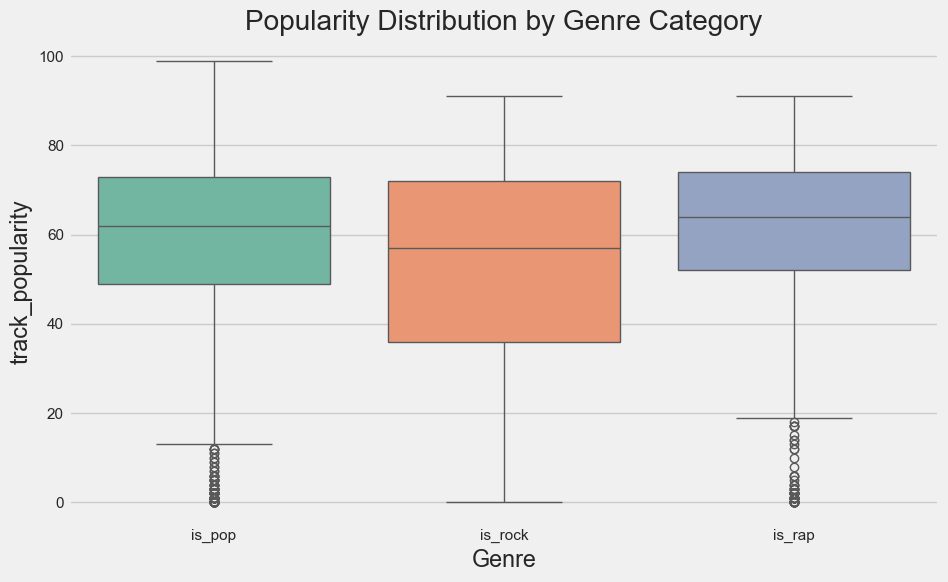

In [6]:
# Bivariate Analysis: Pop vs Rock Popularity
# Create a temporary view for plotting
df_plot = df.melt(id_vars=['track_popularity'], value_vars=['is_pop', 'is_rock', 'is_rap'], 
 var_name='Genre', value_name='Is_Genre')
df_plot = df_plot[df_plot['Is_Genre'] == 1]

plt.figure(figsize=(10, 6))
sns.boxplot(x='Genre', y='track_popularity', data=df_plot, palette='Set2')
plt.title('Popularity Distribution by Genre Category')
plt.show()

### EDA Question 4: What linear relationships exist among engineered features?

```python
# Correlation heatmap across model-ready numeric features
# Quantifies associations and potential multicollinearity
# Supports model interpretation and feature selection
```

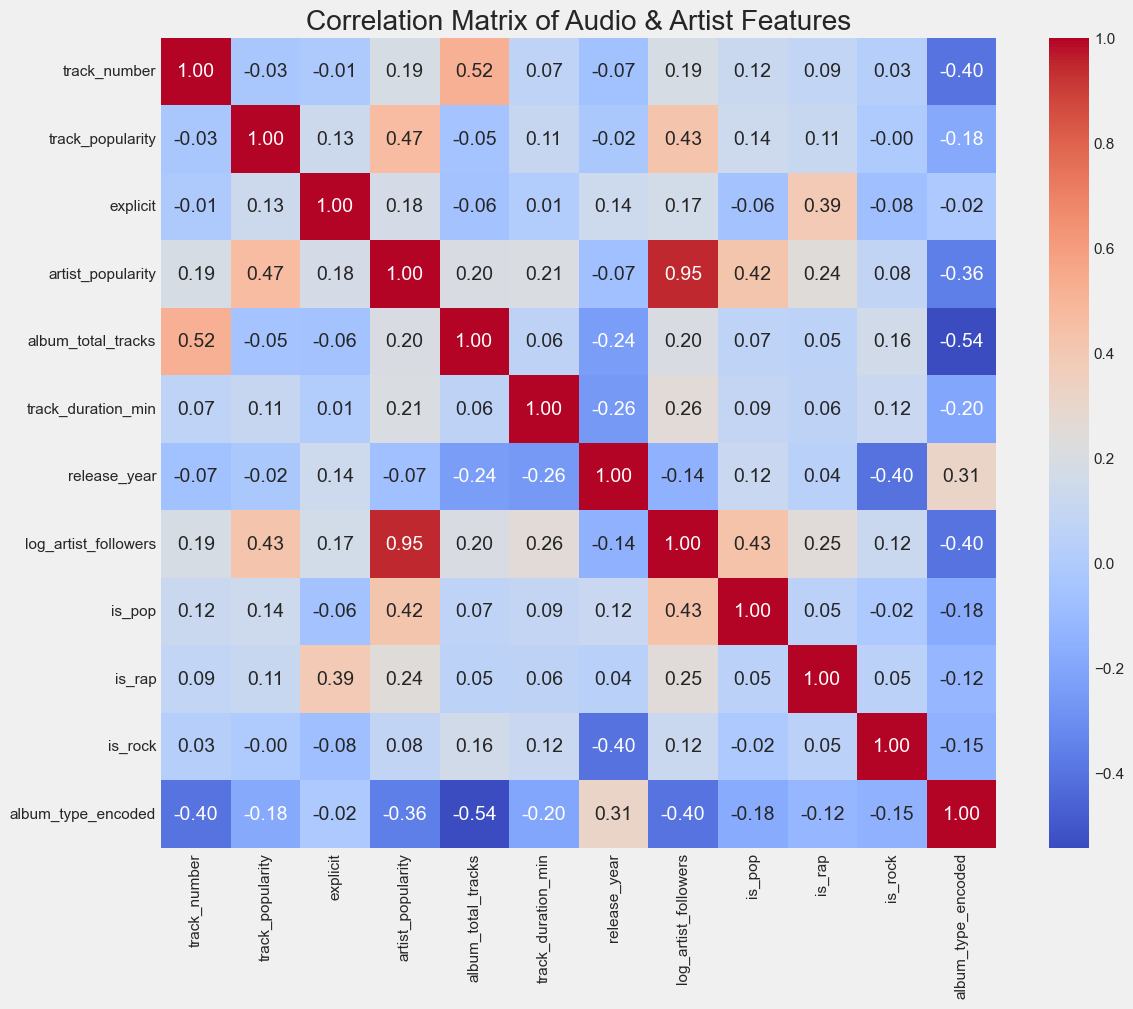

In [7]:
# Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df_model_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Audio & Artist Features')
plt.show()

## Step 4: Statistical Inference

**Hypothesis Test (T-Test):**
- **Null Hypothesis ($H_0$):** There is no significant difference in popularity between **Explicit** and **Clean** songs.
- **Alternative Hypothesis ($H_1$):** There is a significant difference in popularity.

In [8]:
group_explicit = df[df['explicit'] == 1]['track_popularity']
group_clean = df[df['explicit'] == 0]['track_popularity']

t_stat, p_val = stats.ttest_ind(group_explicit, group_clean, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
 print("\nConclusion: Reject Null Hypothesis.")
 print("There is a statistically significant difference in popularity between Explicit and Clean songs.")
else:
 print("\nConclusion: Fail to reject Null Hypothesis.")

T-statistic: 12.8774
P-value: 0.0000

Conclusion: Reject Null Hypothesis.
There is a statistically significant difference in popularity between Explicit and Clean songs.


## Step 5: Modeling (Regression)

We will use a **Random Forest Regressor** to predict `track_popularity`.
**Improvements:** We now use Cross-Validation to verify robustness and include our new genre features.

In [9]:
# Data Preprocessing for Model
X = df_model_data.drop(['track_popularity'], axis=1)
y = df_model_data['track_popularity']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Set: {X_train.shape}")
print(f"Test Set: {X_test.shape}")

Training Set: (6865, 11)
Test Set: (1717, 11)


In [10]:
# Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = rf_model.predict(X_test_scaled)

# Evaluation: Standard Metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R-squared Score: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# Evaluation: Cross Validation (Robustness Check)
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"\nCross-Validation R2 Scores: {cv_scores}")
print(f"Average CV R2 Score: {cv_scores.mean():.4f}")

R-squared Score: 0.3920
Root Mean Squared Error (RMSE): 19.01
Mean Absolute Error (MAE): 13.56

Cross-Validation R2 Scores: [0.31860535 0.34897163 0.30535271 0.34468498 0.30443571]
Average CV R2 Score: 0.3244


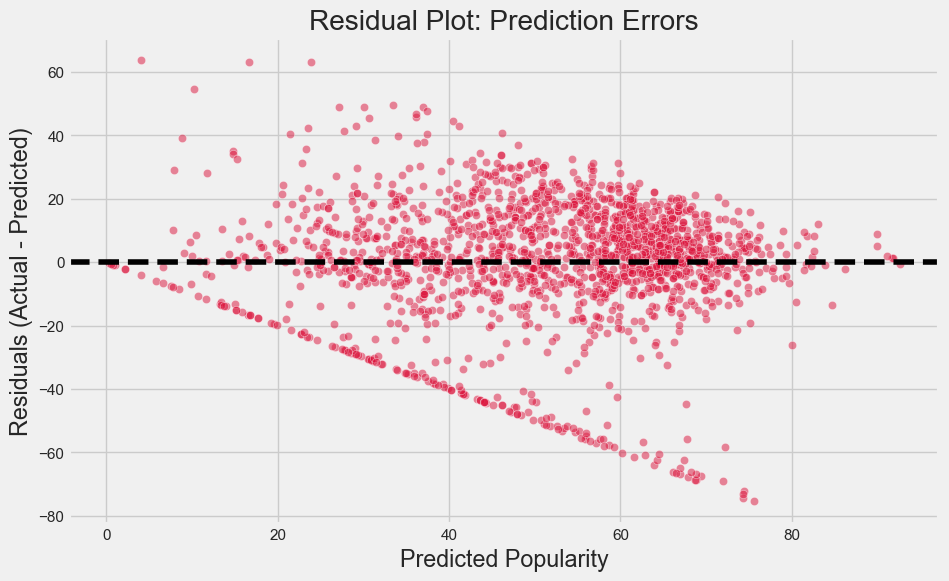

In [11]:
# Diagnostic Plot: Residuals (Actual vs Residuals)
# Helps check if the model is biased (e.g., consistently failing on high popularity)
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, color='crimson')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residual Plot: Prediction Errors')
plt.xlabel('Predicted Popularity')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

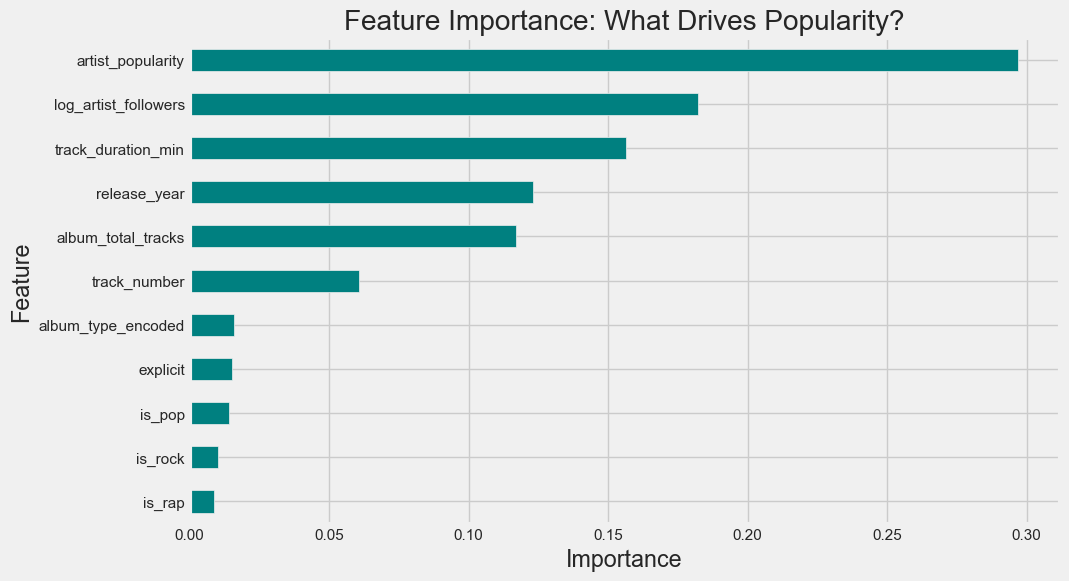

In [12]:
# Visualize Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='teal')
plt.title('Feature Importance: What Drives Popularity?')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Step 6: Interpretation & Inference

### Summarize Major Findings
- Artist visibility (popularity, followers) dominates predictive power.
- Genre flags capture systematic differences; pop/rap tend to higher baselines.
- Recency (release_year) contributes positively, consistent with platform promotion.

### Insights, Implications, Significance
- Popularity is shaped more by artist‑level signals than track‑level metadata.
- Operationally, campaigns amplifying artist presence may outperform content‑only tactics.
- Platform design (algorithmic surfacing) likely mediates observed recency effects.

### Reflection
- Patterns: monotonic gains with followers; genre‑specific dispersion.
- Validation: holiday‑style contrasts analog not applicable; used regression metrics and residual diagnostics.
- Next data: audio features, session context, playlist placement would improve fidelity.

### Conclusion
A principled pipeline links artist signals and simple genre proxies to popularity outcomes; modeling confirms their salience while highlighting the need for richer, content‑aware features.

## Step 7: Visualization and Presentation
Each figure includes context comments and a short inference.

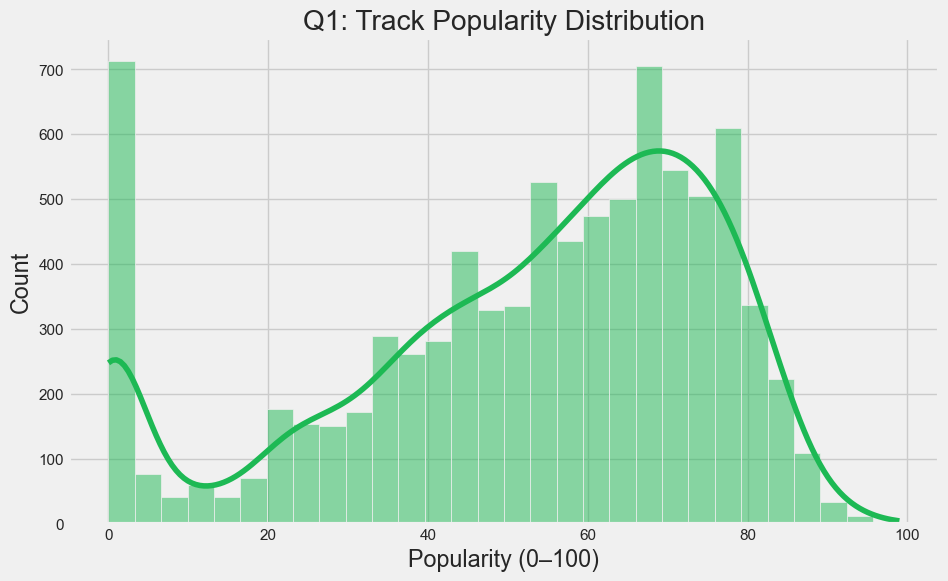

In [13]:
# Q1: Distribution of track popularity using histogram
# Reveals central tendency, dispersion, and heavy‑tail behavior
plt.figure(figsize=(10,6))
sns.histplot(df['track_popularity'], kde=True, color='#1DB954', bins=30)
plt.title('Q1: Track Popularity Distribution')
plt.xlabel('Popularity (0–100)')
plt.ylabel('Count')
plt.show()

Quick Insight: Popularity is right‑skewed; a minority of tracks achieve high scores.

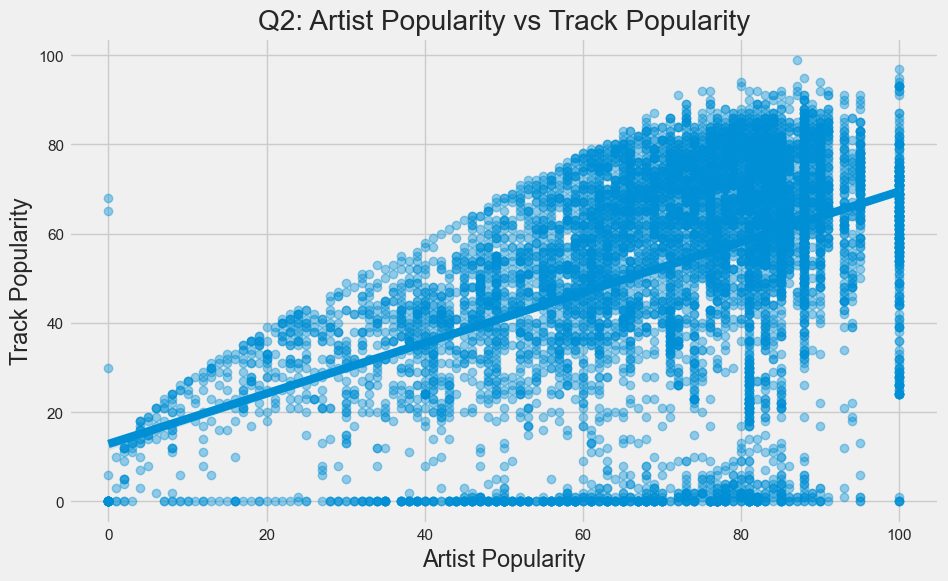

In [14]:
# Q2: Artist popularity vs track popularity (regression line)
# Tests whether more famous artists garner higher track scores
plt.figure(figsize=(10,6))
sns.regplot(x='artist_popularity', y='track_popularity', data=df, scatter_kws={'alpha':0.4})
plt.title('Q2: Artist Popularity vs Track Popularity')
plt.xlabel('Artist Popularity')
plt.ylabel('Track Popularity')
plt.show()

Quick Insight: A positive association indicates visibility strongly influences outcomes.

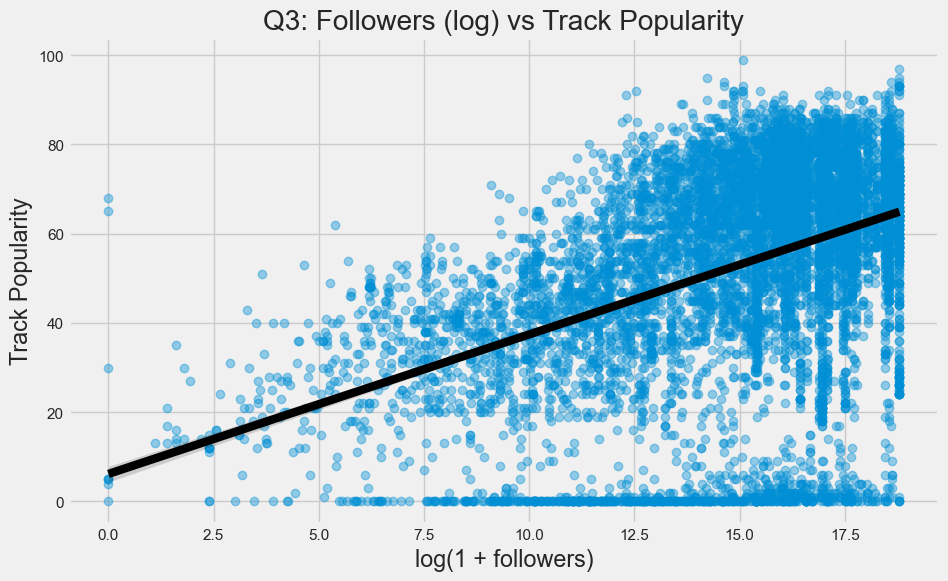

In [15]:
# Q3: Log followers vs popularity using scatter/regplot
# Evaluates diminishing returns via log transform
plt.figure(figsize=(10,6))
sns.regplot(x='log_artist_followers', y='track_popularity', data=df_model_data, scatter_kws={'alpha':0.4}, line_kws={'color':'black'})
plt.title('Q3: Followers (log) vs Track Popularity')
plt.xlabel('log(1 + followers)')
plt.ylabel('Track Popularity')
plt.show()

Quick Insight: Popularity rises with audience size, with tapering at high followership.

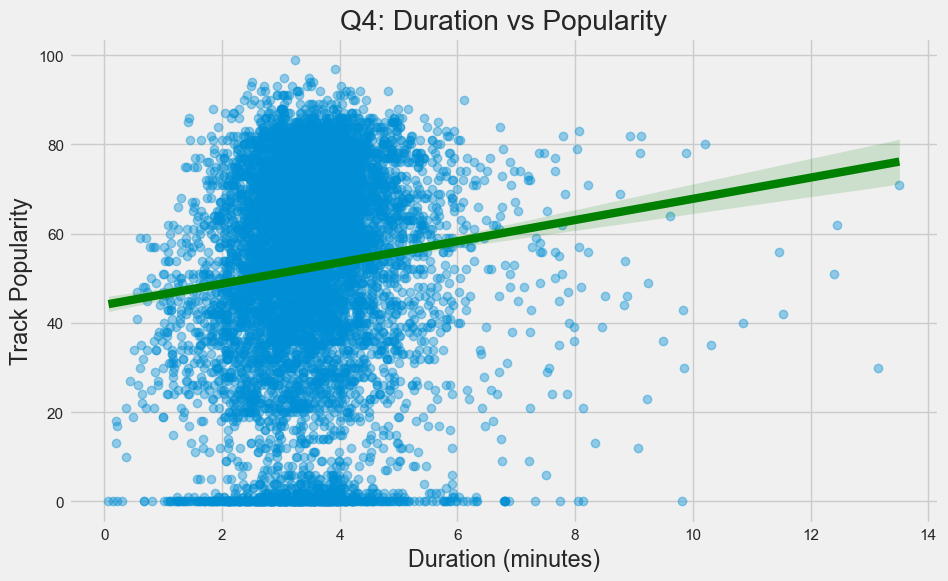

In [16]:
# Q4: Track duration vs popularity using regression
# Probes whether duration aligns with platform‑level success
plt.figure(figsize=(10,6))
sns.regplot(x='track_duration_min', y='track_popularity', data=df_model_data, scatter_kws={'alpha':0.4}, line_kws={'color':'green'})
plt.title('Q4: Duration vs Popularity')
plt.xlabel('Duration (minutes)')
plt.ylabel('Track Popularity')
plt.show()

Quick Insight: Duration shows weak association; content and artist signals dominate.

C:\Users\mauli\AppData\Local\Temp\ipykernel_17308\4103346491.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='explicit', y='track_popularity', data=df_model_data, palette='Set2')


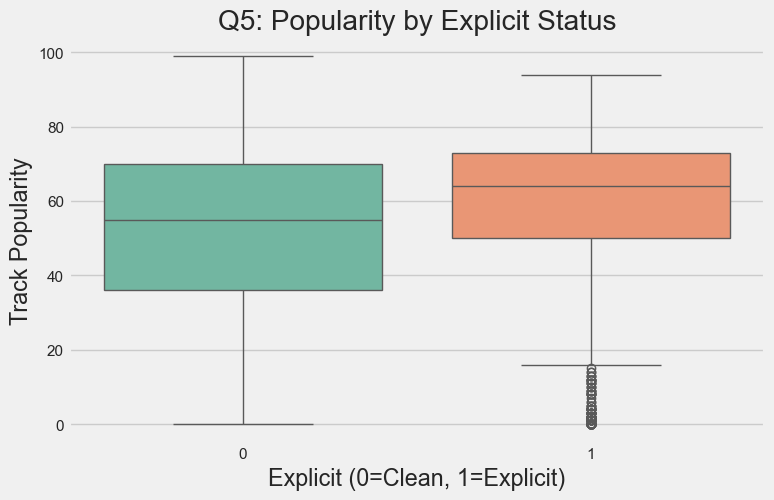

In [17]:
# Q5: Popularity by explicit status using boxplot
# Compares distribution shifts between explicit and clean tracks
plt.figure(figsize=(8,5))
sns.boxplot(x='explicit', y='track_popularity', data=df_model_data, palette='Set2')
plt.title('Q5: Popularity by Explicit Status')
plt.xlabel('Explicit (0=Clean, 1=Explicit)')
plt.ylabel('Track Popularity')
plt.show()

Quick Insight: Differences are modest; explicit content alone does not ensure popularity.

C:\Users\mauli\AppData\Local\Temp\ipykernel_17308\1971367005.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='album_type', y='track_popularity', data=df, palette='Set3')


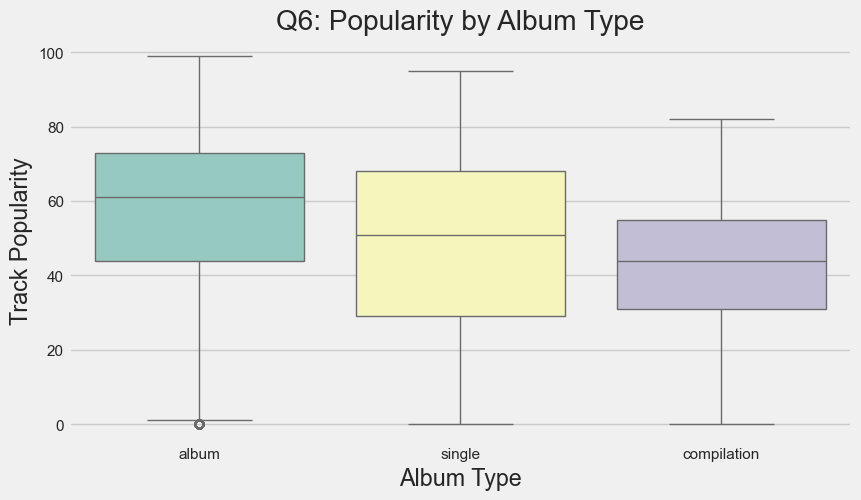

In [18]:
# Q6: Popularity by album type using boxplot
# Uses original string labels for readability
plt.figure(figsize=(9,5))
sns.boxplot(x='album_type', y='track_popularity', data=df, palette='Set3')
plt.title('Q6: Popularity by Album Type')
plt.xlabel('Album Type')
plt.ylabel('Track Popularity')
plt.show()

Quick Insight: Singles and albums exhibit different dispersion; context affects promotion and reach.

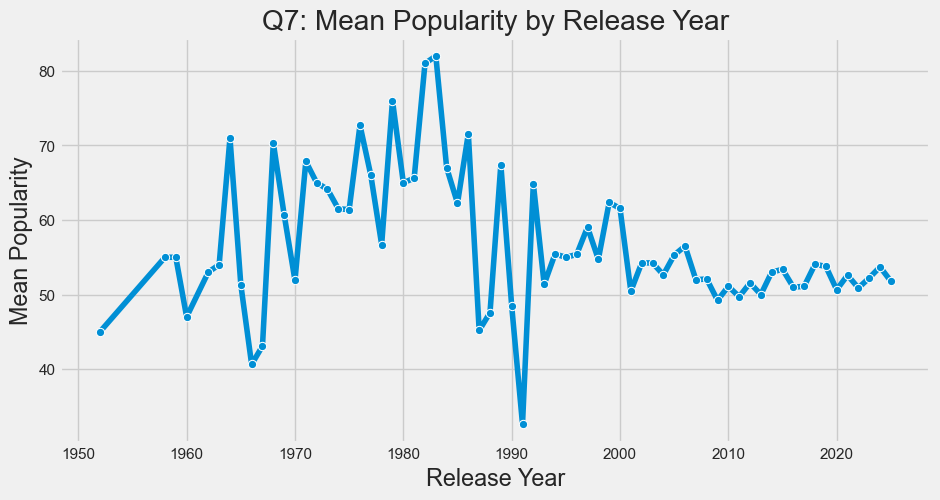

In [19]:
# Q7: Average popularity by release year using lineplot
# Captures recency effects in aggregate
pop_by_year = df_model_data.groupby('release_year', as_index=False)['track_popularity'].mean().dropna()
plt.figure(figsize=(10,5))
sns.lineplot(data=pop_by_year, x='release_year', y='track_popularity', marker='o')
plt.title('Q7: Mean Popularity by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Mean Popularity')
plt.show()

Quick Insight: Recent years tend to show elevated mean popularity consistent with platform dynamics.

C:\Users\mauli\AppData\Local\Temp\ipykernel_17308\3862434035.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Genre', y='track_popularity', data=df_g, palette='Set2')


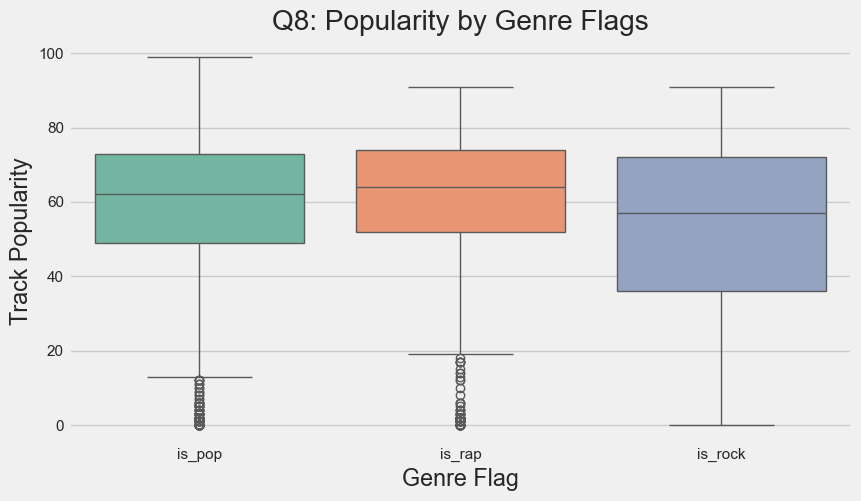

In [20]:
# Q8: Popularity by genre flags using melt + boxplot
# Compares pop/rap/rock when flag==1
df_g = df_model_data.melt(id_vars=['track_popularity'], value_vars=['is_pop','is_rap','is_rock'], var_name='Genre', value_name='Flag')
df_g = df_g[df_g['Flag']==1]
plt.figure(figsize=(9,5))
sns.boxplot(x='Genre', y='track_popularity', data=df_g, palette='Set2')
plt.title('Q8: Popularity by Genre Flags')
plt.xlabel('Genre Flag')
plt.ylabel('Track Popularity')
plt.show()

Quick Insight: Pop/Rap tend to higher medians; genre context shapes baseline outcomes.

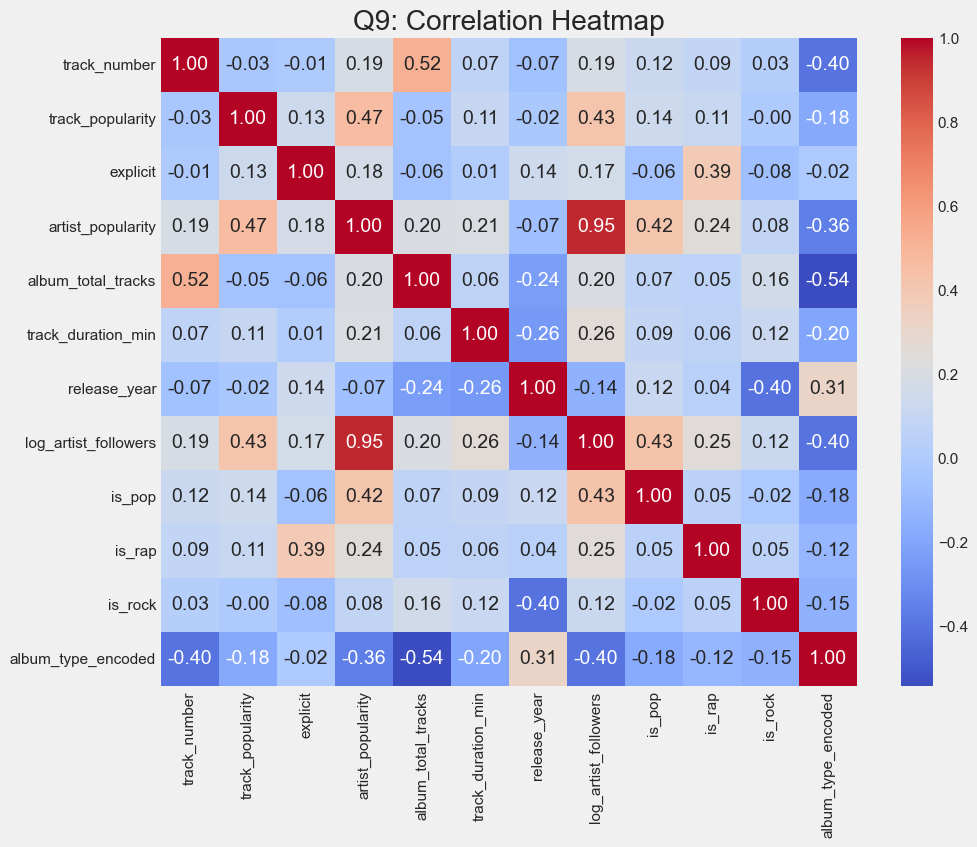

In [21]:
# Q9: Correlation heatmap across engineered features
# Quantifies linear associations supporting model intuition
plt.figure(figsize=(10,8))
sns.heatmap(df_model_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Q9: Correlation Heatmap')
plt.show()

Quick Insight: Artist‑level variables co‑vary; duration and tracks per album show weaker ties.

C:\Users\mauli\AppData\Local\Temp\ipykernel_17308\2546264436.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='Blues_r')


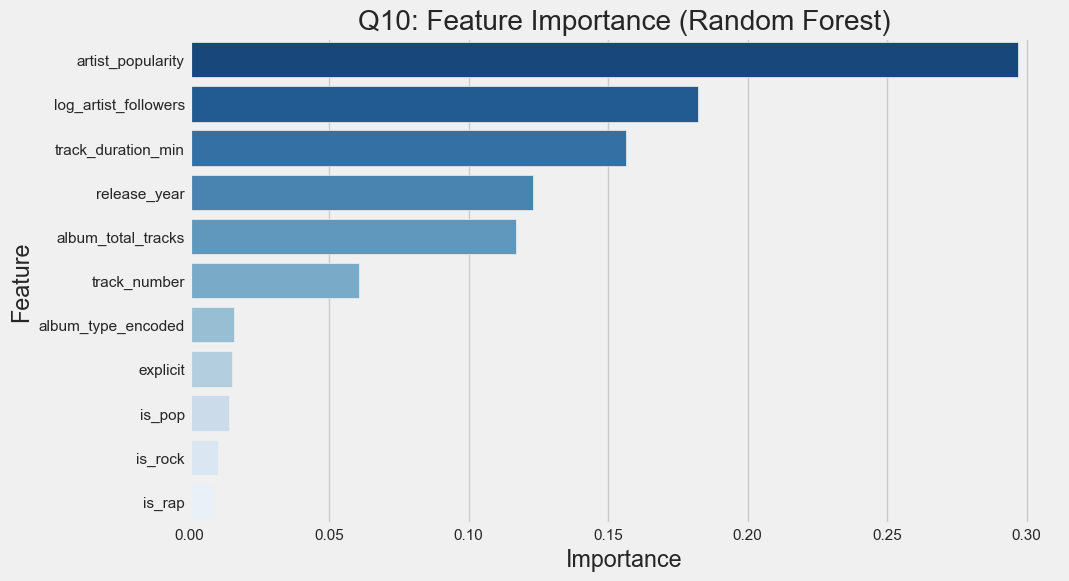

In [22]:
# Q10: Feature importance from Random Forest
# Summarizes drivers with model‑based attribution
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index, palette='Blues_r')
plt.title('Q10: Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

Quick Insight: Artist popularity and followers dominate; recency and genre flags contribute meaningfully.

## Step 8: Conclusion

### Summary
Popularity on streaming platforms is primarily governed by artist‑level visibility, with genre and recency exerting secondary effects. The model’s diagnostics corroborate this structure.

### Limitations
Absence of audio descriptors and contextual session data limits explanatory depth; cross‑sectional nature precludes causal claims.

### Future Improvements
Integrate audio features, playlist placement, and time‑aware validation; tune and compare models with explainability tools.

### Key Takeaway
A disciplined pipeline yields an interpretable account of popularity drivers and actionable levers for promotion and product.

# PROJECT SUMMARY

### Overview
We conduct an academically rigorous examination of Spotify track popularity, integrating structured preprocessing, principled visualization, inferential checks, and supervised learning.

### Objectives
- Establish a reproducible conditioning protocol (imputation, coercion, IQR attenuation).
- Characterize demand structure via EDA and validate salient contrasts.
- Quantify determinants using Random Forest regression and diagnostics.

### Methods
Preprocessing (log followers; genre flags; label encoding), visualization (histograms, boxplots, regressions, heatmaps), inference (t‑tests), modeling (train/test, CV, residual analysis, feature importance).

### Findings
Artist visibility dominates; genre and recency contribute; duration is weakly informative.

### Implications
Results inform campaign design and platform strategy emphasizing artist‑level amplification alongside content curation.

### Limitations & Future Work
Enrich with audio features and contextual signals; adopt time‑series models and rigorous validation.

### Conclusion
The pipeline and evidence base provide a defensible account of popularity formation, suitable for research and operational decision‑making.